##**MASTER THESIS: SENTIMENT ANALYSIS OF CLIMATE CHANGE IN GERMAN NEWS MEDIA USING NLP AND LLM MODELS**

**STEP 1: IMPORTING LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import re
import time
import json
import openai
import os
from transformers import pipeline
import torch
from tqdm.auto import tqdm
import concurrent.futures
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

**Step 2: META DATA CLEANING & PRE-PROCESSING**

In [ ]:
files = [
    "bz_scrapped.csv",
    "faz_scrapped.csv",
    "spiegel_scrapped.csv",
    "sz_scrapped.csv",
    "welt_scrapped.csv",
    "zeit_scrapped.csv"
]

In [ ]:
dfs = []
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.encode("latin1", errors="ignore").decode("utf-8", errors="ignore")
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text
def fix_row(row):
    headline = str(row.get("Headline", ""))
    intro = str(row.get("Intro", ""))
    content = str(row.get("Content", ""))
    if len(headline) > 200:
        content = headline + " " + content
        headline = headline[:150]
    if len(intro) > len(content):
        content = intro
    if len(content) < 100 and len(intro) > 50:
        content = intro + " " + content
    if len(intro) < 20 and len(content) > 100:
        intro = content.split(".")[0]
    return pd.Series([headline, intro, content])
def is_valid(row):
    headline = str(row["Headline"])
    content = str(row["Content"])
    if len(content) < 150:
        return False
    if len(headline.strip()) < 5:
        return False
    if len(re.findall(r"[^\w\s]", content)) > len(content) * 0.35:
        return False
    if content.count(",") > 200:
        return False
    return True
for file in files:
    df = pd.read_csv(file, encoding="utf-8", sep=",", quotechar='"', engine="python", on_bad_lines="skip")
    for col in ["Headline", "Intro", "Content"]:
        if col in df.columns:
            df[col] = df[col].apply(clean_text)
    df[["Headline", "Intro", "Content"]] = df.apply(fix_row, axis=1)
    before = len(df)
    df = df[df.apply(is_valid, axis=1)]
    after = len(df)
    dfs.append(df)
combined_df = pd.concat(dfs, ignore_index=True)

In [ ]:
combined_df = combined_df.drop_duplicates(subset=["Content"])
combined_df = combined_df[(combined_df["Content"].str.len() > 150) & (combined_df["Headline"].str.len() > 5)]
combined_df = combined_df.reset_index(drop=True)
combined_df.to_csv("german_climate_news_dataset.csv", index=False, encoding="utf-8-sig")

**STEP 3: FEATURE ENGINEERING => ACTOR EXTACTION AND CLASSIFICATION**

**Calling XML ROberta and paraphrase multilingual models**

In [ ]:
device = 0 if torch.cuda.is_available() else -1
actor_extraction = pipeline("ner", model="Davlan/xlm-roberta-base-ner-hrl",
    aggregation_strategy="simple",device=device)
actor_classification = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
tqdm.pandas()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: Davlan/xlm-roberta-base-ner-hrl
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Text Cleaning for actor extraction**

In [ ]:
base_df = pd.read_csv(r"german_climate_news_dataset.csv")
base_df["Headline"] = base_df["Headline"].fillna("")
base_df["Intro"] = base_df["Intro"].fillna("")
base_df["Content"] = base_df["Content"].fillna("")
base_df["text"] = (base_df["Headline"] + ". " + base_df["Intro"] + ". " + base_df["Content"])
base_df["text"] = base_df["text"].str.replace("\n", " ")
base_df["text"] = base_df["text"].str.replace(r"\s+", " ", regex=True)
base_df["text"] = base_df["text"].str.strip()
base_df["text"] = base_df["text"].str[:1500]

**Defining functions for actor cleaning, removing duplicates and extracting actors**

In [ ]:
def actor_cleaning(name):
    name = name.strip()
    name = re.sub(r"[^A-Za-z\s\-]", "", name)
    name = re.sub(r"\s+", " ", name)
    if len(name) < 3:
        return None
    stop_words = ["der", "die", "das", "und", "ein"]
    if name.lower() in stop_words:
        return None
    return name
def actors_duplicate(actors):
    final = []
    for a in sorted(actors, key=len, reverse=True):
        if not any(a.lower() in f.lower() for f in final):
            final.append(a)
    return final[:8]
def actors_extract(text):
    try:
        ents = actor_extraction(text)
        actors = []
        for e in ents:
            if e["entity_group"] in ["PER", "ORG"]:
                name = actor_cleaning(e["word"])
                if name:
                    actors.append(name)
        return actors_duplicate(actors)
    except:
        return []
base_df["actors"] = base_df["text"].progress_apply(actors_extract)

  0%|          | 0/28422 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


**Defining function for preparing actor text and defining categories**

In [ ]:
def actor_context(text, actor):
    sentences = re.split(r'[.!?]', text)
    for s in sentences:
        if actor in s:
            return s.strip()
    return text[:200]
actor_main = ["government", "politician", "company", "scientist",
    "activist","international organization", "media", "ngo", "others"]
categories = actor_classification.encode(actor_main)

**Defining functions for actor classification and classifying actors**

In [ ]:
def classify_actor(actor, text):
    context = actor_context(text, actor)
    emb = actor_classification.encode([context])
    sim = cosine_similarity(emb, categories)[0]
    best_idx = sim.argmax()
    return actor_main[best_idx]

def classify_actor_list(row):
    actors = row["actors"]
    text = row["text"]
    result = {}
    for actor in actors:
        result[actor] = classify_actor(actor, text)
    return result

base_df["actor_types"] = base_df.progress_apply(classify_actor_list, axis=1)

  0%|          | 0/28422 [00:00<?, ?it/s]

**Saving the file to csv**

In [ ]:
base_df.to_csv("/content/climate_news_final_dataset.csv", index=False)

**STEP 4: ACTOR LEVEL SENTIMENT ANALYSIS**

In [ ]:
df_beta = pd.read_csv(r"climate_news_final_dataset.csv")
print("Total numberof rows and columns: ", df_beta.shape)
print(df_beta.columns)
df = df_beta.copy()

Total numberof rows and columns:  (28422, 17)
Index(['URL', 'Source', 'Language', 'Published_Date', 'Keyword_Matched',
       'Article_Classification', 'Headline', 'Intro', 'Content',
       'Content_Length', 'Sentence_Count', 'Actors', 'Actor_Count', 'Author',
       'text', 'actors', 'actor_types'],
      dtype='object')


**Cleaning text for and preparing data set for actor level sentiment analysis**

In [ ]:
def clean_text(x):
    x = str(x)
    x = re.sub(r'^text\s+', '', x, flags=re.IGNORECASE)
    x = re.sub(r'\s+', ' ', x)
    return x.strip()
df["text"] = df["text"].fillna("").astype(str).progress_apply(clean_text)

def fix_actors(x):
    x = str(x)
    if x == "nan":
        return []
    x = x.replace("[", "").replace("]", "")
    x = x.replace("'", "").replace('"', "")
    return [i.strip() for i in x.split(",") if i.strip()]
df["actors_clean"] = df["actors"].progress_apply(fix_actors)

def fix_actor_types(x):
    x = str(x)
    if x == "nan":
        return {}
    x = x.replace("{", "").replace("}", "")
    x = x.replace("[", "").replace("]", "")
    x = x.replace("'", "").replace('"', "")
    result = {}
    for p in x.split(","):
        if ":" in p:
            try:
                k, v = p.split(":", 1)
                result[k.strip()] = v.strip()
            except:
                pass
    return result
df["actor_types_clean"] = df["actor_types"].progress_apply(fix_actor_types)

def build_actor_rows(row):
    actors = row["actors_clean"]
    types_dict = row["actor_types_clean"]
    rows = []
    for a in actors:
        rows.append({"actor": a, "actor_type": types_dict.get(a, "other"),
            "text": row["text"],"Source": row["Source"], "Published_Date": row["Published_Date"]})
    return rows
df["actor_rows"] = df.progress_apply(build_actor_rows, axis=1)
df_actor = df.explode("actor_rows").reset_index(drop=True)
df_actor = pd.concat([df_actor.drop(columns=["actor_rows"]), df_actor["actor_rows"].apply(pd.Series)], axis=1)
df_actor = df_actor.loc[:, ~df_actor.columns.duplicated()]
print("After explode:", df_actor.shape)
def extract_actor_text(row):
    text = str(row["text"]).lower()
    actor = str(row["actor"]).lower()
    if not text.strip():
        return ""
    sentences = re.split(r'(?<=[.!?])\s+', text)
    actor_parts = actor.split()
    matched_sentences = []
    for s in sentences:
        score = sum(1 for part in actor_parts if part in s)
        if score >= 1:
            matched_sentences.append(s.strip())
    return " ".join(matched_sentences)
df_actor["actor_text"] = df_actor.progress_apply(extract_actor_text, axis=1)
df_actor["actor_text"] = df_actor["actor_text"].fillna("")
df_actor = df_actor[df_actor["actor_text"].str.strip() != ""]
df_actor = df_actor[df_actor["actor_text"].str.len() > 20]
df_actor = df_actor[df_actor["actor"].notna()]
df_actor = df_actor[df_actor["actor"].str.strip() != ""]
df_actor = df_actor[df_actor["actor_type"].notna()]
df_actor = df_actor[df_actor["actor_type"].str.strip() != ""]
print("After cleaning:", df_actor.shape)
df_actor_final = df_actor[[
    "actor",
    "actor_type",
    "actor_text",
    "Source",
    "Published_Date"
]]
df_actor_final.to_csv("actor_level_dataset.csv", index=False)
print(df_actor_final.head())

  0%|          | 0/28422 [00:00<?, ?it/s]

  0%|          | 0/28422 [00:00<?, ?it/s]

  0%|          | 0/28422 [00:00<?, ?it/s]

  0%|          | 0/28422 [00:00<?, ?it/s]

After explode: (107556, 22)


  0%|          | 0/107556 [00:00<?, ?it/s]

After cleaning: (105413, 23)
                         actor                  actor_type  \
0               Regina Stephan                    activist   
1                  Lilli Gomez                         ngo   
2  Berliner Staatsanwaltschaft                       media   
3            Letzte Generation  international organization   
4                rbb Recherche                   scientist   

                                          actor_text Source  \
0  die angeklagte regina stephan (22) sagt: hab w...   B.Z.   
1  freispruch fr klima-lilli in berlin. aber dies...   B.Z.   
2  die berliner staatsanwaltschaft prft laut dem ...   B.Z.   
3  wegen bergriffen auf mitglieder der gruppe let...   B.Z.   
4  wegen bergriffen auf mitglieder der gruppe let...   B.Z.   

          Published_Date  
0  13.01.2025, 10:44 Uhr  
1  13.01.2025, 10:44 Uhr  
2  28.07.2023, 07:47 Uhr  
3  28.07.2023, 07:47 Uhr  
4  28.07.2023, 07:47 Uhr  


**Calling Oliver Guhr Sentiment Model**

In [ ]:
sentiment_model = pipeline("sentiment-analysis", model="oliverguhr/german-sentiment-bert", device=device)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

**Performing actor level sentiment analysis**



In [ ]:
def batch_sentiment(texts, batch_size=32):
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        preds = sentiment_model(batch, truncation=True, padding=True,max_length=512)
        results.extend([p["label"].lower() for p in preds])
    return results
df_actor["actor_sentiment"] = batch_sentiment(df_actor["actor_text"].tolist())
df_actor_final = df_actor[["actor","actor_type","actor_text","Source","Published_Date","actor_sentiment",
    "Article_Classification","Keyword_Matched"]].copy()

  0%|          | 0/3295 [00:00<?, ?it/s]

**Saving the actor sentiment analysis to csv**

In [ ]:
df_actor_final.to_csv("/content/actor_analysis.csv", index=False)

**STEP 5: Article Level Sentiment Analysis**

In [ ]:
articel_df = pd.read_csv(r"climate_news_final_dataset.csv")
print("Total number of rows and columns: ", articel_df.shape)
df.head()

Total number of rows and columns:  (28422, 17)


,URL,Source,Language,Published_Date,Keyword_Matched,Article_Classification,Headline,Intro,Content,Content_Length,Sentence_Count,Actors,Actor_Count,Author,text,actors,actor_types,actors_clean,actor_types_clean,actor_rows
0,https://www.bz-berlin.de/berlin/klima-lilli-fr...,B.Z.,de,"13.01.2025, 10:44 Uhr",klima,Climate_Policy,Freispruch fr Klima-Lilli in Berlin,Wieder stand Deutschlands schlimmste Klima-Rad...,Wieder stand Deutschlands schlimmste Klima-Rad...,2956,36,"Aktion gutheiße!, CDU, Christopher Förster, Gr...",9,Stefan Peter,Freispruch fr Klima-Lilli in Berlin. Wieder st...,"['Regina Stephan', 'Lilli Gomez']","{'Regina Stephan': 'activist', 'Lilli Gomez': ...","[Regina Stephan, Lilli Gomez]","{'Regina Stephan': 'activist', 'Lilli Gomez': ...","[{'actor': 'Regina Stephan', 'actor_type': 'ac..."
1,https://www.bz-berlin.de/berlin/angriffe-auf-k...,B.Z.,de,"28.07.2023, 07:47 Uhr",klima,Climate_Policy,Angriffe auf Klima-Kleber mehr als 100 Verfahren!,Wegen bergriffen auf Mitglieder der Gruppe Let...,Wegen bergriffen auf Mitglieder der Gruppe Let...,1690,16,"Gruppe Letzte Generation, RBB",2,B.Z./dpa,Angriffe auf Klima-Kleber mehr als 100 Verfahr...,"['Berliner Staatsanwaltschaft', 'Letzte Genera...","{'Berliner Staatsanwaltschaft': 'media', 'Letz...","[Berliner Staatsanwaltschaft, Letzte Generatio...","{'Berliner Staatsanwaltschaft': 'media', 'Letz...","[{'actor': 'Berliner Staatsanwaltschaft', 'act..."
2,https://www.bz-berlin.de/berlin/wer-soll-diese...,B.Z.,de,"19.05.2023, 06:21 Uhr",klima,Climate_Policy,Wer soll diesen Klima-Kleber-Irrsinn eigentlic...,Nicht mal am Feiertag lassen die Klima-Radikal...,Nicht mal am Feiertag lassen die Klima-Radikal...,3296,38,"Audi, B.Z., Berliner FDP, CDU-Abgeordnete, Chr...",7,Maren Wittge,Wer soll diesen Klima-Kleber-Irrsinn eigentlic...,"['Technische Einsatzeinheit', 'Polizei']","{'Technische Einsatzeinheit': 'government', 'P...","[Technische Einsatzeinheit, Polizei]","{'Technische Einsatzeinheit': 'government', 'P...","[{'actor': 'Technische Einsatzeinheit', 'actor..."
3,https://www.bz-berlin.de/berlin/klima-chaoten-...,B.Z.,de,"22.08.2023, 21:37 Uhr",klima,Climate_Geopolitics,Klima-Chaoten drohen Berlin mit Drama,Die sogenannte Letzte Generation hat weitere S...,Die sogenannte Letzte Generation hat weitere S...,1599,13,"Carla Hinrichs, Lars Werner, Roger Hallam, Werner",4,Isabel Pfannkuche,Klima-Chaoten drohen Berlin mit Drama. Die sog...,"['ning Jeschke', 'Roger Hallam', 'Lars Werner'...","{'ning Jeschke': 'international organization',...","[ning Jeschke, Roger Hallam, Lars Werner, a Hi...","{'ning Jeschke': 'international organization',...","[{'actor': 'ning Jeschke', 'actor_type': 'inte..."
4,https://www.bz-berlin.de/polizei/razzia-bei-kl...,B.Z.,de,"13.12.2022, 12:26 Uhr",klima,Climate_Policy,Razzia bei Klima-Klebern der Letzten Generation,Sind die Klima-Kleber der Gruppe Letzte Genera...,Sind die Klima-Kleber der Gruppe Letzte Genera...,2803,27,"BER, CDU-Abgeordneten, Christopher Förster, Cy...",6,Matthias Lukaschewitsch,Razzia bei Klima-Klebern der Letzten Generatio...,"['Staatsanwaltschaft Neuruppin', 'Letzte Gener...","{'Staatsanwaltschaft Neuruppin': 'activist', '...","[Staatsanwaltschaft Neuruppin, Letzte Generati...","{'Staatsanwaltschaft Neuruppin': 'activist', '...","[{'actor': 'Staatsanwaltschaft Neuruppin', 'ac..."


**Cleanign text and preparing the dataset for article sentiment analysis**

In [ ]:
def clean_text(x):
    x = str(x)
    x = re.sub(r'\s+', ' ', x)
    return x.strip()
articel_df["Headline"] = articel_df["Headline"].fillna("").astype(str)
articel_df["Intro"] = articel_df["Intro"].fillna("").astype(str)
articel_df["Content"] = articel_df["Content"].fillna("").astype(str)
articel_df["article_text"] = (articel_df["Headline"] + ". " + articel_df["Intro"] + ". " + articel_df["Content"])
articel_df["article_text"] = articel_df["article_text"].progress_apply(clean_text)
print(articel_df["article_text"].head())

  0%|          | 0/28422 [00:00<?, ?it/s]

0    Freispruch fr Klima-Lilli in Berlin. Wieder st...
1    Angriffe auf Klima-Kleber mehr als 100 Verfahr...
2    Wer soll diesen Klima-Kleber-Irrsinn eigentlic...
3    Klima-Chaoten drohen Berlin mit Drama. Die sog...
4    Razzia bei Klima-Klebern der Letzten Generatio...
Name: article_text, dtype: object


**Performing article sentiment analysis using Oliver Guhr model**

In [ ]:
def batch_sentiment(texts, batch_size=2):
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        preds = sentiment_model(batch,truncation=True,padding=True,max_length=512)
        results.extend([p["label"].lower() for p in preds])
    return results

articel_df["article_sentiment"] = batch_sentiment(articel_df["article_text"].tolist())
print(articel_df["article_sentiment"].value_counts())

  0%|          | 0/14211 [00:00<?, ?it/s]

article_sentiment
neutral     25747
negative     2661
positive       14
Name: count, dtype: int64


**Saving the article analysis to csv**

In [ ]:
articel_df.to_csv("/content/article_sentiment.csv", index=False)

**STEP 6: ARTICLE LEVEL FRAMING ANALYSIS**

**Defining variables for api key, naming input and output csv, batch size, number of cahracters and calling LLM model (GPT-4o-mini)**

In [ ]:
openai.api_key  = "Please paste here you api key. I am removing API key here because if someone else uses it then it can lead to billinng cost as GPT-40-mini is not free!!!"
MODEL            = "gpt-4o-mini"
INPUT_CSV        = "climate_news_final_dataset.csv"
OUTPUT_CSV       = "/content/articel_level_framing.csv"
CHECKPOINT_EVERY = 500
BATCH_SIZE       = 10
TEXT_CHARS       = 200
SLEEP_BETWEEN    = 0.3

**Prompt for the LLM Model**

In [ ]:
SYSTEM_PROMPT = """You are a media framing analyst for German climate journalism.
You will receive a numbered list of articles. Each article has:
- classification: the topic category
- text: headline + short excerpt (in German)
For EACH article return a JSON array where each element has exactly these fields:
{  "id": <the number given>,
  "content_frame": <see valid values below>,
  "tone": <see valid values below>,
  "valence": <see valid values below>}
VALID VALUES — use ONLY these exact strings, no variations, no new categories:
content_frame (pick the single dominant frame):
  "Conflict"         — clash between groups (activists vs police, protesters vs public)
  "Legal/Judicial"   — courts, verdicts, criminal proceedings, raids, fines
  "Economic"         — costs, financial damage, CO2 taxes, prices, budgets, housing
  "Moral/Ethical"    — right vs wrong, values, legitimacy of protest or policy
  "Political"        — party reactions, government policy, elections, international politics
  "Security/Threat"  — danger to public order, criminal organisation framing
  "Human Interest"   — personal stories, individual profiles, lifestyle
  "Informational"    — scientific facts, statistics, neutral event reporting, research findings
tone (the sentiment of the OUTLET or AUTHOR — not the factual outcome of events):
  "Negative"  — the outlet frames the subject critically, with alarm or hostility
  "Neutral"   — balanced, factual, no clear editorial sentiment
  "Mixed"     — both critical and sympathetic elements present
  "Positive"  — the outlet frames the subject favourably or optimistically
framing (the article's implicit stance toward climate urgency and climate action):
  "Pro-climate-action"              — treats climate change as urgent, supports action or policy
  "Neutral/Informational"           — factual reporting, no editorial stance on climate
  "Skeptical/Anti-climate-action"   — dismisses urgency, frames climate policy as harmful or exaggerated
IMPORTANT RULES:
- Use ONLY the exact label strings listed above. Do not invent new categories.
- If unsure between two frames, pick the most dominant one.
- tone reflects the OUTLET perspective, not what happens to the people in the article.
- Return ONLY a valid JSON array — no markdown, no explanation, no extra text.
Example output: [{"id":1,"content_frame":"Conflict","tone":"Negative","valence":"Skeptical/Anti-climate-action"},
{"id":2,"content_frame":"Informational","tone":"Neutral","valence":"Neutral/Informational"}]"""
VALID_FRAMES  = {"Conflict","Legal/Judicial","Economic","Moral/Ethical",
                 "Political","Security/Threat","Human Interest","Informational"}
VALID_TONES   = {"Negative","Neutral","Mixed","Positive"}
VALID_VALENCE = {"Pro-climate-action","Neutral/Informational","Skeptical/Anti-climate-action"}
FRAME_CORRECTIONS = {
    "Geopolitical":  "Political",
    "Geopolitics":   "Political",
    "Judicial":      "Legal/Judicial",
    "Legal":         "Legal/Judicial",
    "Security":      "Security/Threat",
    "Threat":        "Security/Threat",
    "Human-Interest":"Human Interest",}
TONE_CORRECTIONS = {
    "Negative/Critical": "Negative",
    "Critical":          "Negative",
    "Positive/Favourable":"Positive",}
VALENCE_CORRECTIONS = {
    "Skeptical":                    "Skeptical/Anti-climate-action",
    "Anti-climate-action":          "Skeptical/Anti-climate-action",
    "Pro-climate":                  "Pro-climate-action",
    "Neutral":                      "Neutral/Informational",}

**Defining variables for labelling and batch size**

In [ ]:
def correct_label(value, valid_set, corrections=None):
    if value in valid_set:
        return value
    if corrections and value in corrections:
        return corrections[value]
    return "Error"

def build_batch_prompt(batch):
    lines = []
    for item in batch:
        snippet = item["text"].strip()[:TEXT_CHARS].replace("\n", " ")
        lines.append(
            f"{item['id']}. classification: {item['classification']} | "
            f"text: {snippet}")
    return "\n".join(lines)

**Defining labels for dealing with the JSON output from LLM, api calling per batch and saving the results into csv**

In [ ]:
def parse_response(raw: str, batch: list) -> list:
    raw = raw.replace("```json", "").replace("```", "").strip()
    try:
        results = json.loads(raw)
        if isinstance(results, list):
            return results
    except json.JSONDecodeError:
        pass
    recovered = []
    for match in re.finditer(r'\{[^{}]+\}', raw):
        try:
            obj = json.loads(match.group())
            if all(k in obj for k in ("id", "content_frame", "tone", "valence")):
                recovered.append(obj)
        except json.JSONDecodeError:
            continue
    if recovered:
        recovered_ids = {r["id"] for r in recovered}
        for item in batch:
            if item["id"] not in recovered_ids:
                recovered.append({
                    "id": item["id"],
                    "content_frame": "Error",
                    "tone": "Error",
                    "valence": "Error",})
        print(f"  [partial recovery: {len(recovered_ids)}/{len(batch)} objects salvaged]",
              end=" ", flush=True)
        return recovered
    return [{"id": item["id"], "content_frame": "Error",
             "tone": "Error", "valence": "Error"} for item in batch]
def call_api(batch, retries=3):
    prompt = build_batch_prompt(batch)
    for attempt in range(retries):
        try:
            response = openai.chat.completions.create(
                model=MODEL,
                temperature=0,
                max_tokens=600,
                messages=[{"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": prompt},],)
            raw = response.choices[0].message.content.strip()
            results = parse_response(raw, batch)
            for r in results:
                r["content_frame"] = correct_label(
                    r.get("content_frame", "Error"), VALID_FRAMES, FRAME_CORRECTIONS)
                r["tone"] = correct_label(
                    r.get("tone", "Error"), VALID_TONES, TONE_CORRECTIONS)
                r["valence"] = correct_label(
                    r.get("valence", "Error"), VALID_VALENCE, VALENCE_CORRECTIONS)
            return results
        except openai.RateLimitError:
            wait = 2 ** (attempt + 1)
            print(f"  Rate limit — waiting {wait}s...")
            time.sleep(wait)
        except openai.APIError as e:
            print(f"  API error (attempt {attempt+1}): {e}")
            time.sleep(2)
        except Exception as e:
            print(f"  Unexpected error (attempt {attempt+1}): {e}")
            time.sleep(2)
    return [{"id": item["id"], "content_frame": "Error",
             "tone": "Error", "valence": "Error"} for item in batch]
def main():
    print("Loading dataset...")
    df = pd.read_csv(INPUT_CSV, sep=None, engine="python")
    required = {"Source", "Keyword_Matched", "Article_Classification", "text"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}\nFound: {list(df.columns)}")
    total = len(df)
    print(f"Total articles: {total}")
    if os.path.exists(OUTPUT_CSV):
        done_df = pd.read_csv(OUTPUT_CSV)
        resume_offset = len(done_df)
        print(f"Checkpoint found — resuming from row {resume_offset}")
    else:
        done_df = pd.DataFrame()
        resume_offset = 0
    remaining = total - resume_offset
    n_batches  = remaining // BATCH_SIZE + (1 if remaining % BATCH_SIZE else 0)
    print(f"Remaining: {remaining} articles | Batches: {n_batches}\n")
    results_map = {}
    for i in range(resume_offset, total, BATCH_SIZE):
        batch_rows = df.iloc[i : i + BATCH_SIZE]
        batch = []
        for local_idx, (_, row) in enumerate(batch_rows.iterrows()):
            article_id = i + local_idx + 1
            batch.append({"id":             article_id,
                "classification": str(row["Article_Classification"]).strip(),
                "text":           str(row["text"]).strip(),})
        batch_num = (i - resume_offset) // BATCH_SIZE + 1
        print(f"Batch {batch_num}/{n_batches} | rows {i+1}–{i+len(batch)} ... ",
              end="", flush=True)
        results = call_api(batch)
        for r in results:
            results_map[r["id"]] = r
        print("done")
        rows_done = i + len(batch)
        is_checkpoint = (rows_done - resume_offset) % CHECKPOINT_EVERY == 0
        is_final      = rows_done >= total
        if is_checkpoint or is_final:
            new_slice = df.iloc[resume_offset : rows_done].copy()
            ids_in_slice = range(resume_offset + 1, rows_done + 1)
            new_slice["content_frame"] = [results_map.get(aid, {}).get("content_frame", "Error")
                for aid in ids_in_slice]
            new_slice["tone"] = [results_map.get(aid, {}).get("tone", "Error")
                for aid in ids_in_slice]
            new_slice["valence"] = [results_map.get(aid, {}).get("valence", "Error")
                for aid in ids_in_slice]
            combined = pd.concat([done_df, new_slice], ignore_index=True)
            combined.to_csv(OUTPUT_CSV, index=False)
            print(f"  Checkpoint saved ({rows_done}/{total} rows total)")
        time.sleep(SLEEP_BETWEEN)
    final = pd.read_csv(OUTPUT_CSV)
    errors = (final["content_frame"] == "Error").sum()
    print(f"\n{'='*55}")
    print(f"Complete. {total} articles processed.")
    print(f"Errors: {errors} ({errors/total*100:.1f}%)")
    print(f"Output: {OUTPUT_CSV}")
    print(f"\n--- content_frame ---")
    print(final["content_frame"].value_counts().to_string())
    print(f"\n--- tone ---")
    print(final["tone"].value_counts().to_string())
    print(f"\n--- valence ---")
    print(final["valence"].value_counts().to_string())
if __name__ == "__main__":
    main()

**STEP 7: ANSWERING RESEARCH QUESTIONS**

**RQ1: What are the most trending climate topics?**

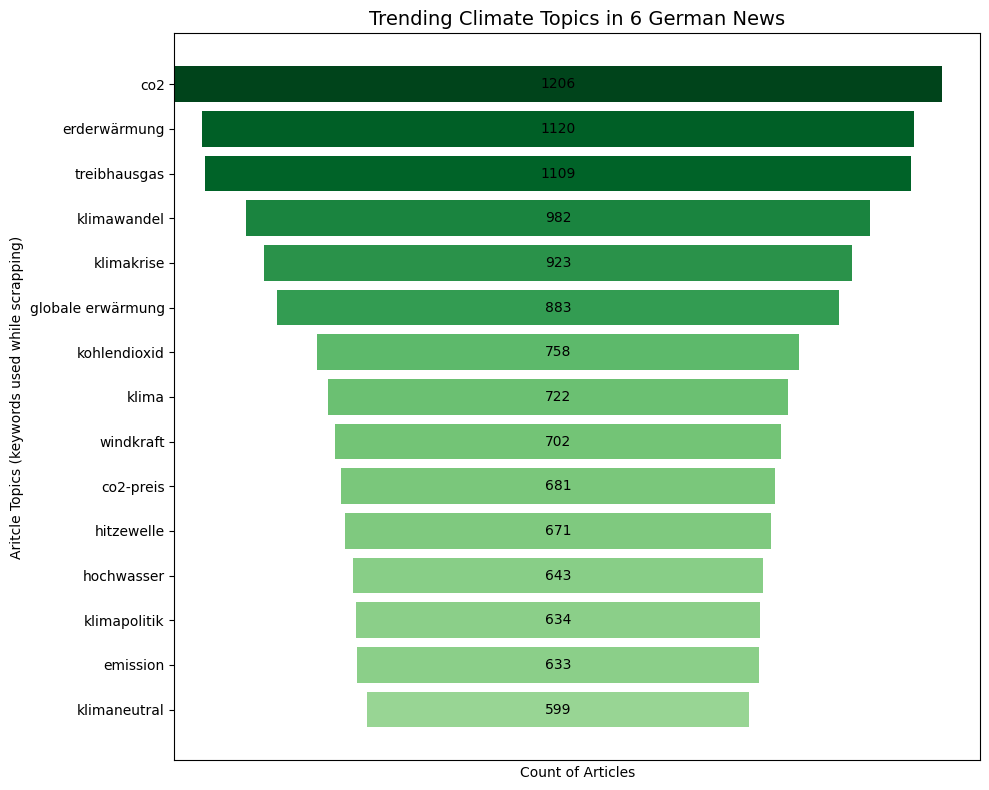

In [ ]:
df = pd.read_csv("german_climate_news_dataset.csv")
df = df[["Keyword_Matched"]].dropna().copy()
df["Keyword_Matched"] = df["Keyword_Matched"].str.lower().str.strip()
keyword_counts = df["Keyword_Matched"].value_counts().head(15)
values = keyword_counts.values
labels = keyword_counts.index
norm = (values - values.min()) / (values.max() - values.min())
norm = 0.4 + 0.6 * norm
colors = plt.cm.Greens(norm)
max_value = values.max()
left = (max_value - values) / 2
plt.figure(figsize=(10, 8))
plt.barh(labels, values, left=left, color=colors)
plt.gca().invert_yaxis()
plt.xticks([])
for i, v in enumerate(values):
    plt.text(max_value/2, i, str(v), ha='center', va='center', color='black', fontsize=10)
plt.title("Trending Climate Topics in 6 German News", fontsize=14)
plt.ylabel("Aritcle Topics (keywords used while scrapping)")
plt.xlabel("Count of Articles")
plt.tight_layout()
plt.savefig("keyword_funnel_chart.png", dpi=300, bbox_inches="tight")
plt.show()

**RQ2: Does German News Media uses different sentiments in various climate articles?**

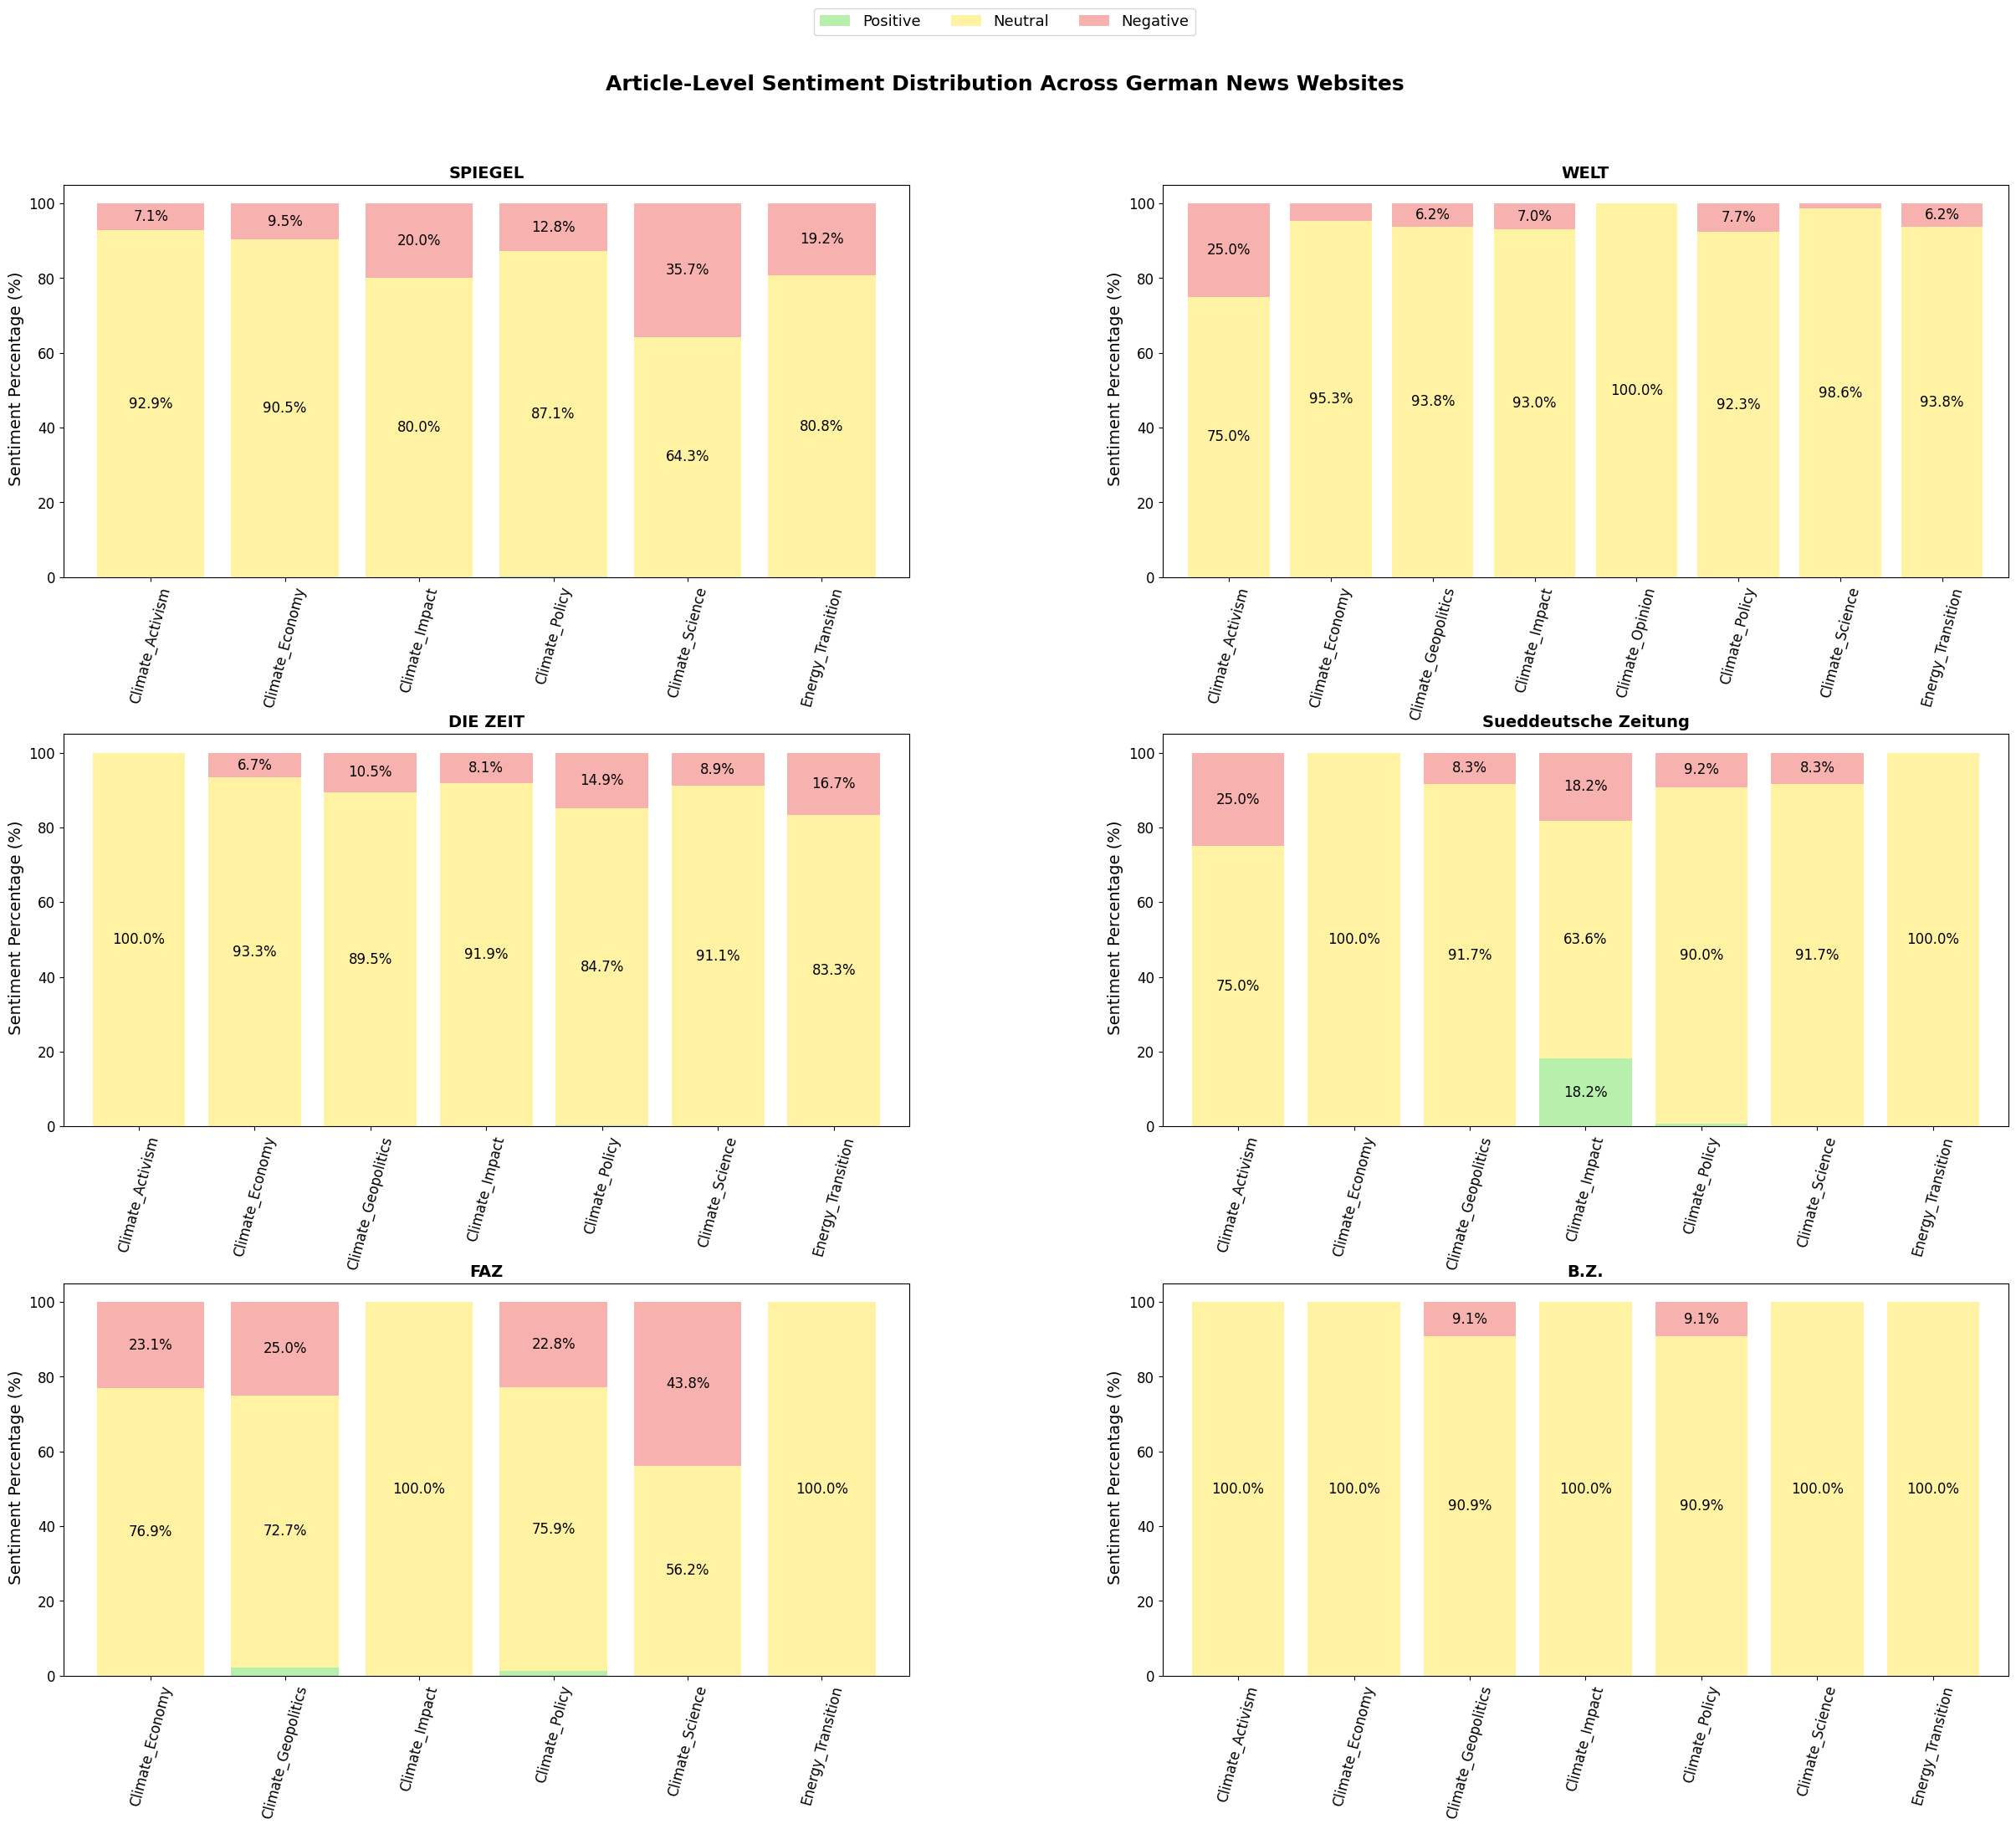

In [ ]:
article_graph_df = pd.read_csv("article_sentiment.csv")
article_graph_df = article_graph_df[["Source", "Article_Classification", "article_sentiment"]].dropna().copy()
article_graph_df["article_sentiment"] = article_graph_df["article_sentiment"].str.lower().str.strip()
article_graph_df["Article_Classification"] = article_graph_df["Article_Classification"].str.strip()
article_graph_df = article_graph_df[
    ~article_graph_df["Article_Classification"].str.lower().isin(["other", "other_climate"])]
top_sources = article_graph_df["Source"].value_counts().head(6).index.tolist()
article_graph_df = article_graph_df[article_graph_df["Source"].isin(top_sources)]
fig, axes = plt.subplots(3, 2, figsize=(30, 22))
axes = axes.flatten()
colors = ["#b7f0ad", "#fff3a3", "#f7b2b0"]
for i, source in enumerate(top_sources):
    sub_df = article_graph_df[article_graph_df["Source"] == source]
    count_df = (sub_df.groupby(["Article_Classification", "article_sentiment"]).size().unstack(fill_value=0))
    for col in ["positive", "neutral", "negative"]:
        if col not in count_df.columns:
            count_df[col] = 0
    count_df = count_df[["positive", "neutral", "negative"]]
    percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100
    percent_df.plot(kind="bar", stacked=True, ax=axes[i], color=colors, legend=False, width=0.8)
    for container in axes[i].containers:
        labels = []
        for v in container.datavalues:
            if v > 5:
                labels.append(f"{v:.1f}%")
            else:
                labels.append("")
        axes[i].bar_label(container, labels=labels, label_type="center", fontsize=12)
    axes[i].set_title(source, fontsize=14, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(" Sentiment Percentage (%)", fontsize=14)
    axes[i].tick_params(axis='x', rotation=75, labelsize=12)
    axes[i].tick_params(axis='y', labelsize=12)
fig.legend(["Positive", "Neutral", "Negative"], loc="upper center", ncol=3,fontsize=13, bbox_to_anchor=(0.5, 1.02))
plt.suptitle("Article-Level Sentiment Distribution Across German News Websites", fontsize=18, fontweight="bold")
plt.subplots_adjust(hspace=0.4, wspace=0.3, top = 0.92)
plt.savefig("article_sentiment_analysis.png", dpi=400, bbox_inches="tight")
plt.show()

**RQ 3: What are the framing distribution (Left vs Neutral vs RIght Leaning) on article level in German News Media?**

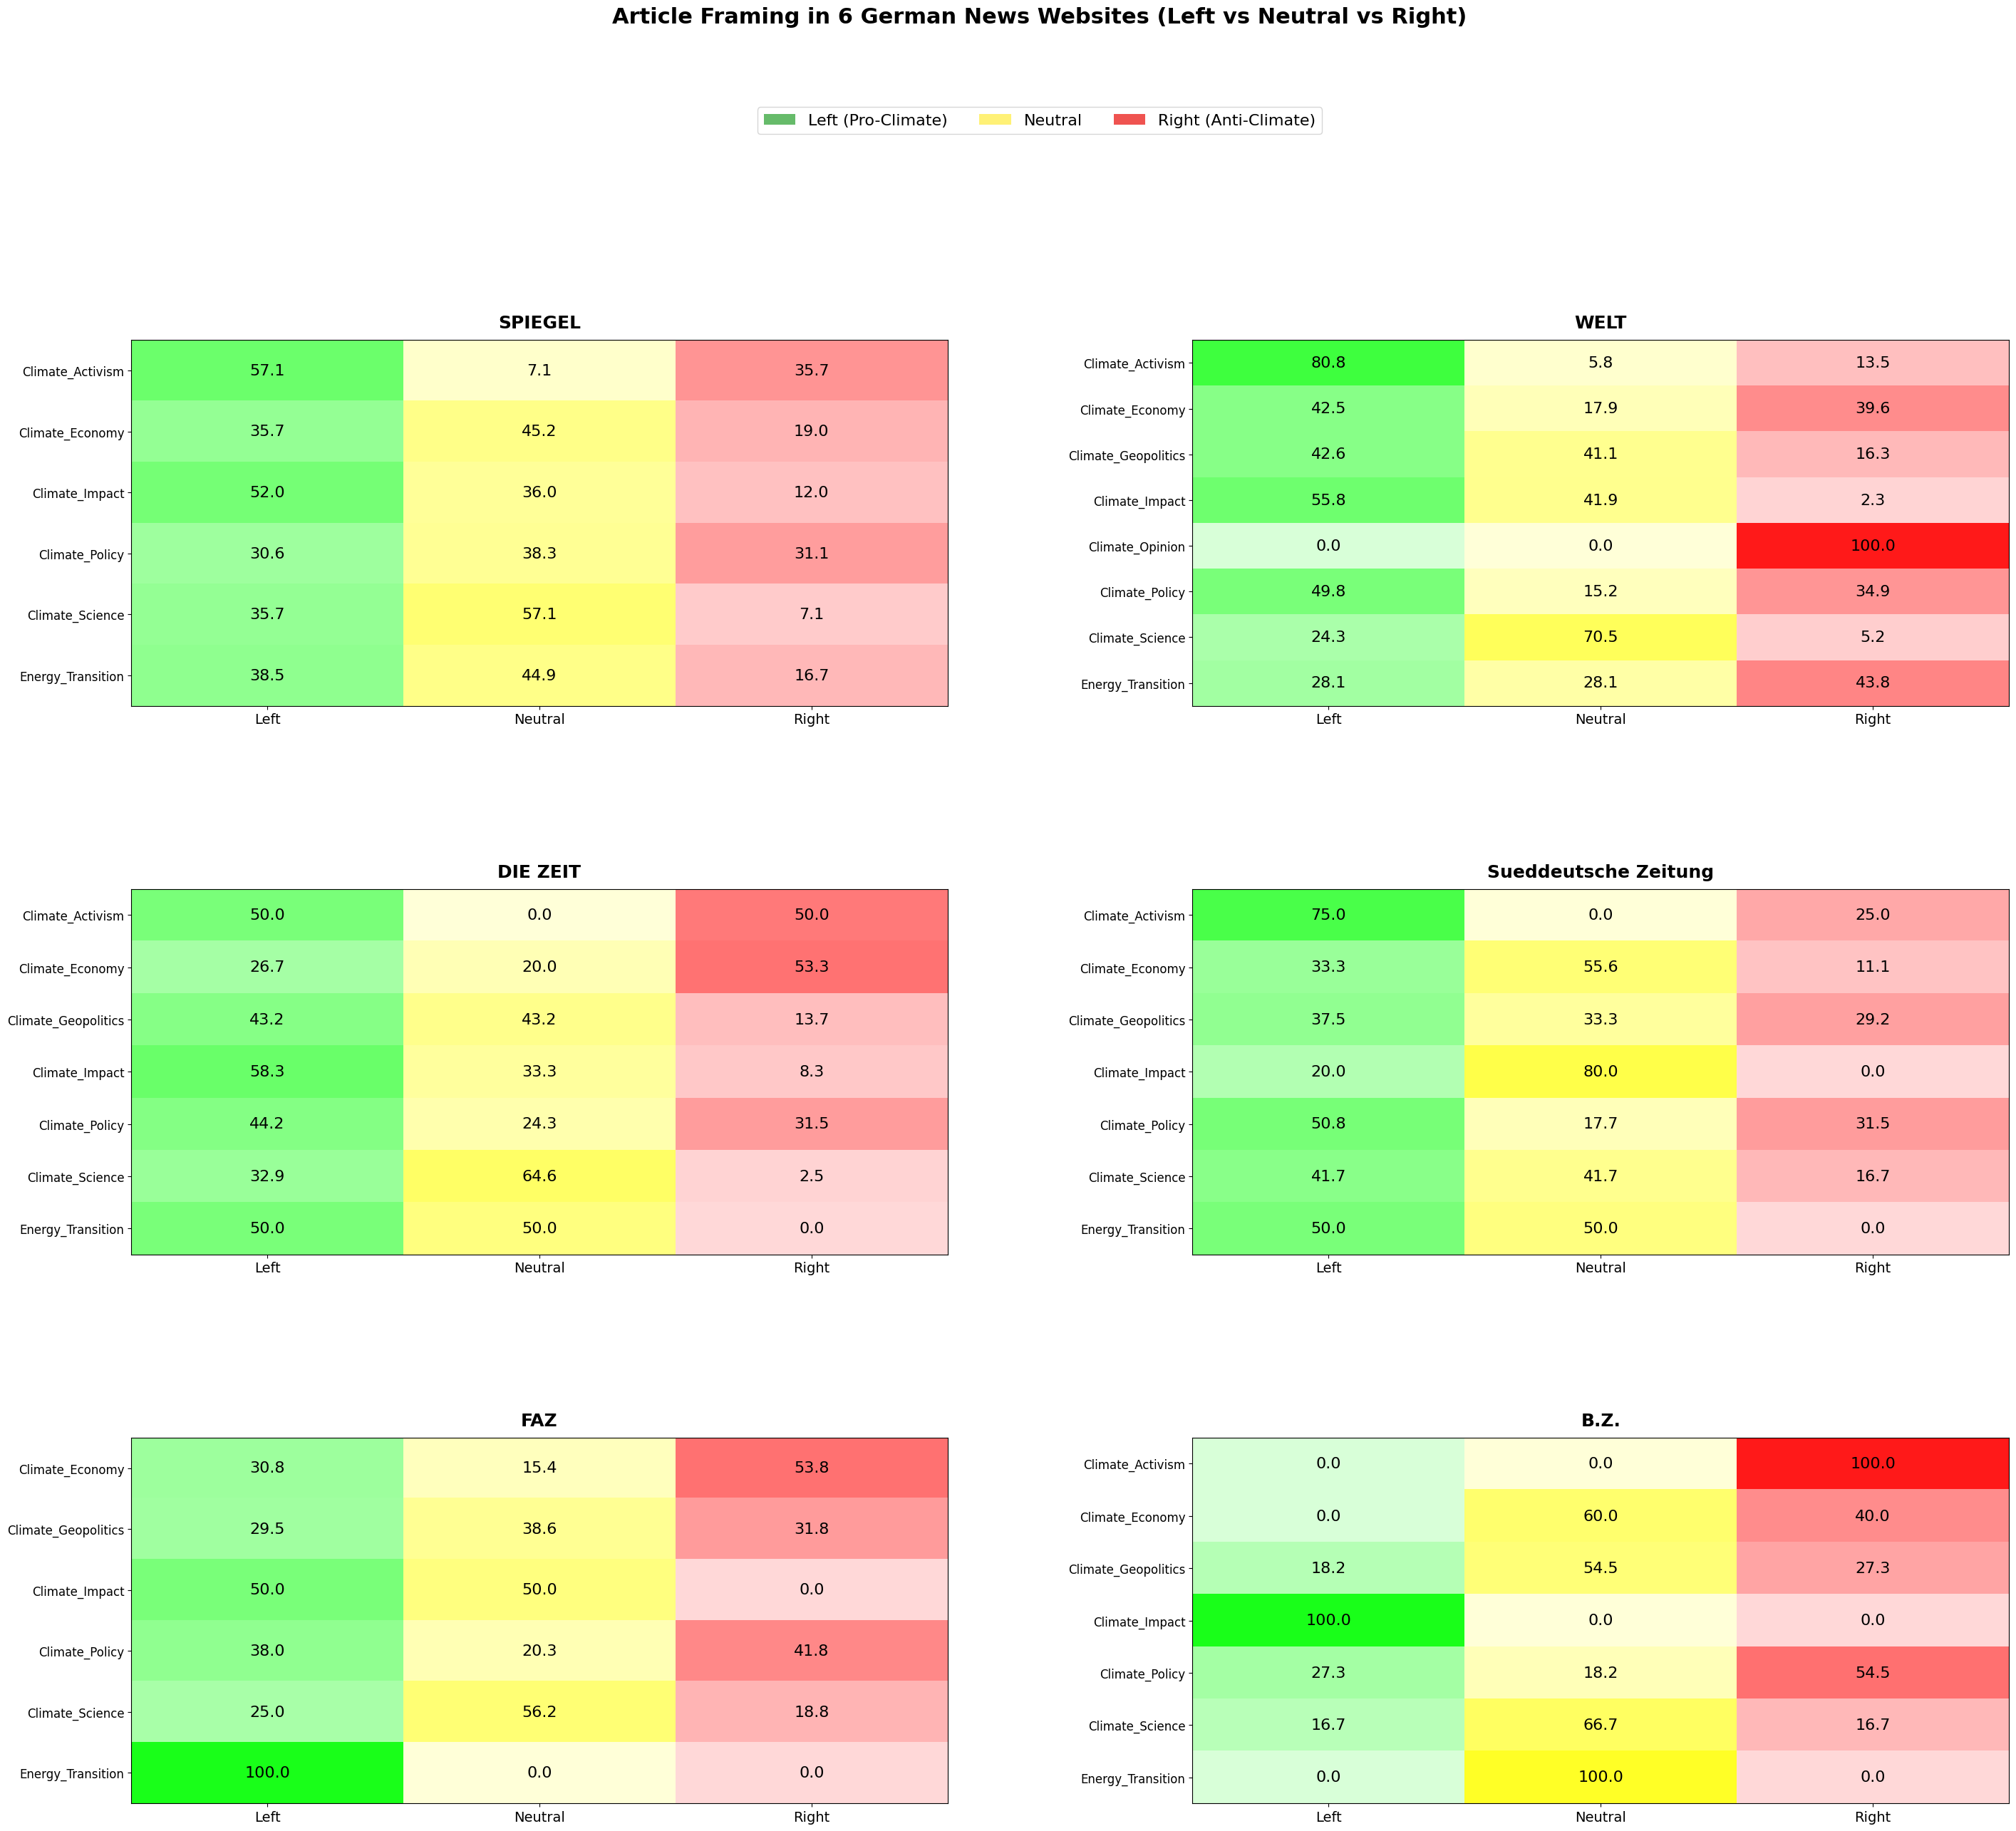

In [ ]:
df = pd.read_csv("articel_level_framing.csv")
VALENCE_MAP = {
    "Pro-climate-action": "Left",
    "Neutral/Informational": "Neutral",
    "Skeptical/Anti-climate-action": "Right",}
df["leaning"] = df["valence"].map(VALENCE_MAP)
df = df[~df["Article_Classification"].str.lower().isin(["other", "other_climate"])]
top_sources = df["Source"].value_counts().head(6).index.tolist()
df = df[df["Source"].isin(top_sources)]
fig, axes = plt.subplots(3, 2, figsize=(34, 26))
axes = axes.flatten()
for i, source in enumerate(top_sources):
    sub = df[df["Source"] == source]
    ct = pd.crosstab(sub["Article_Classification"],sub["leaning"],normalize="index") * 100
    ct = ct.reindex(columns=["Left", "Neutral", "Right"]).fillna(0)
    rgb = np.zeros((ct.shape[0], ct.shape[1], 3))
    for r in range(ct.shape[0]):
        for c in range(ct.shape[1]):
            val = ct.iloc[r, c] / 100
            if c == 0:
                rgb[r, c] = [0.85 - 0.75 * val, 1.0, 0.85 - 0.75 * val]
            elif c == 1:
                rgb[r, c] = [1.0, 1.0, 0.85 - 0.7 * val]
            elif c == 2:
                rgb[r, c] = [1.0, 0.85 - 0.75 * val, 0.85 - 0.75 * val]
    axes[i].imshow(rgb, aspect='auto')
    for r in range(ct.shape[0]):
        for c in range(ct.shape[1]):
            axes[i].text(c, r, f"{ct.iloc[r, c]:.1f}", ha='center', va='center', fontsize=16, color="black")
    axes[i].set_xticks(range(3))
    axes[i].set_xticklabels(["Left", "Neutral", "Right"], fontsize=14)
    axes[i].set_yticks(range(len(ct.index)))
    axes[i].set_yticklabels(ct.index, fontsize=12)
    axes[i].set_title(source, fontsize=18, fontweight='bold', pad=12)
for j in range(len(top_sources), len(axes)):
    fig.delaxes(axes[j])
legend_elements = [
    Patch(facecolor="#66bb6a", label="Left (Pro-Climate)"),
    Patch(facecolor="#fff176", label="Neutral"),
    Patch(facecolor="#ef5350", label="Right (Anti-Climate)")]
fig.legend(handles=legend_elements, loc="upper center", ncol=3, fontsize=16, bbox_to_anchor=(0.5, 1.03))
plt.suptitle("Article Framing in 6 German News Websites (Left vs Neutral vs Right)", fontsize=22, fontweight='bold', y=1.08)
plt.subplots_adjust(hspace=0.5, wspace=0.3, top=0.9)
plt.savefig("article_framing.png", dpi=500, bbox_inches="tight")
plt.show()

**RQ4: Does German News media uses different sentiment tones when certain actors are involved in climate news?**

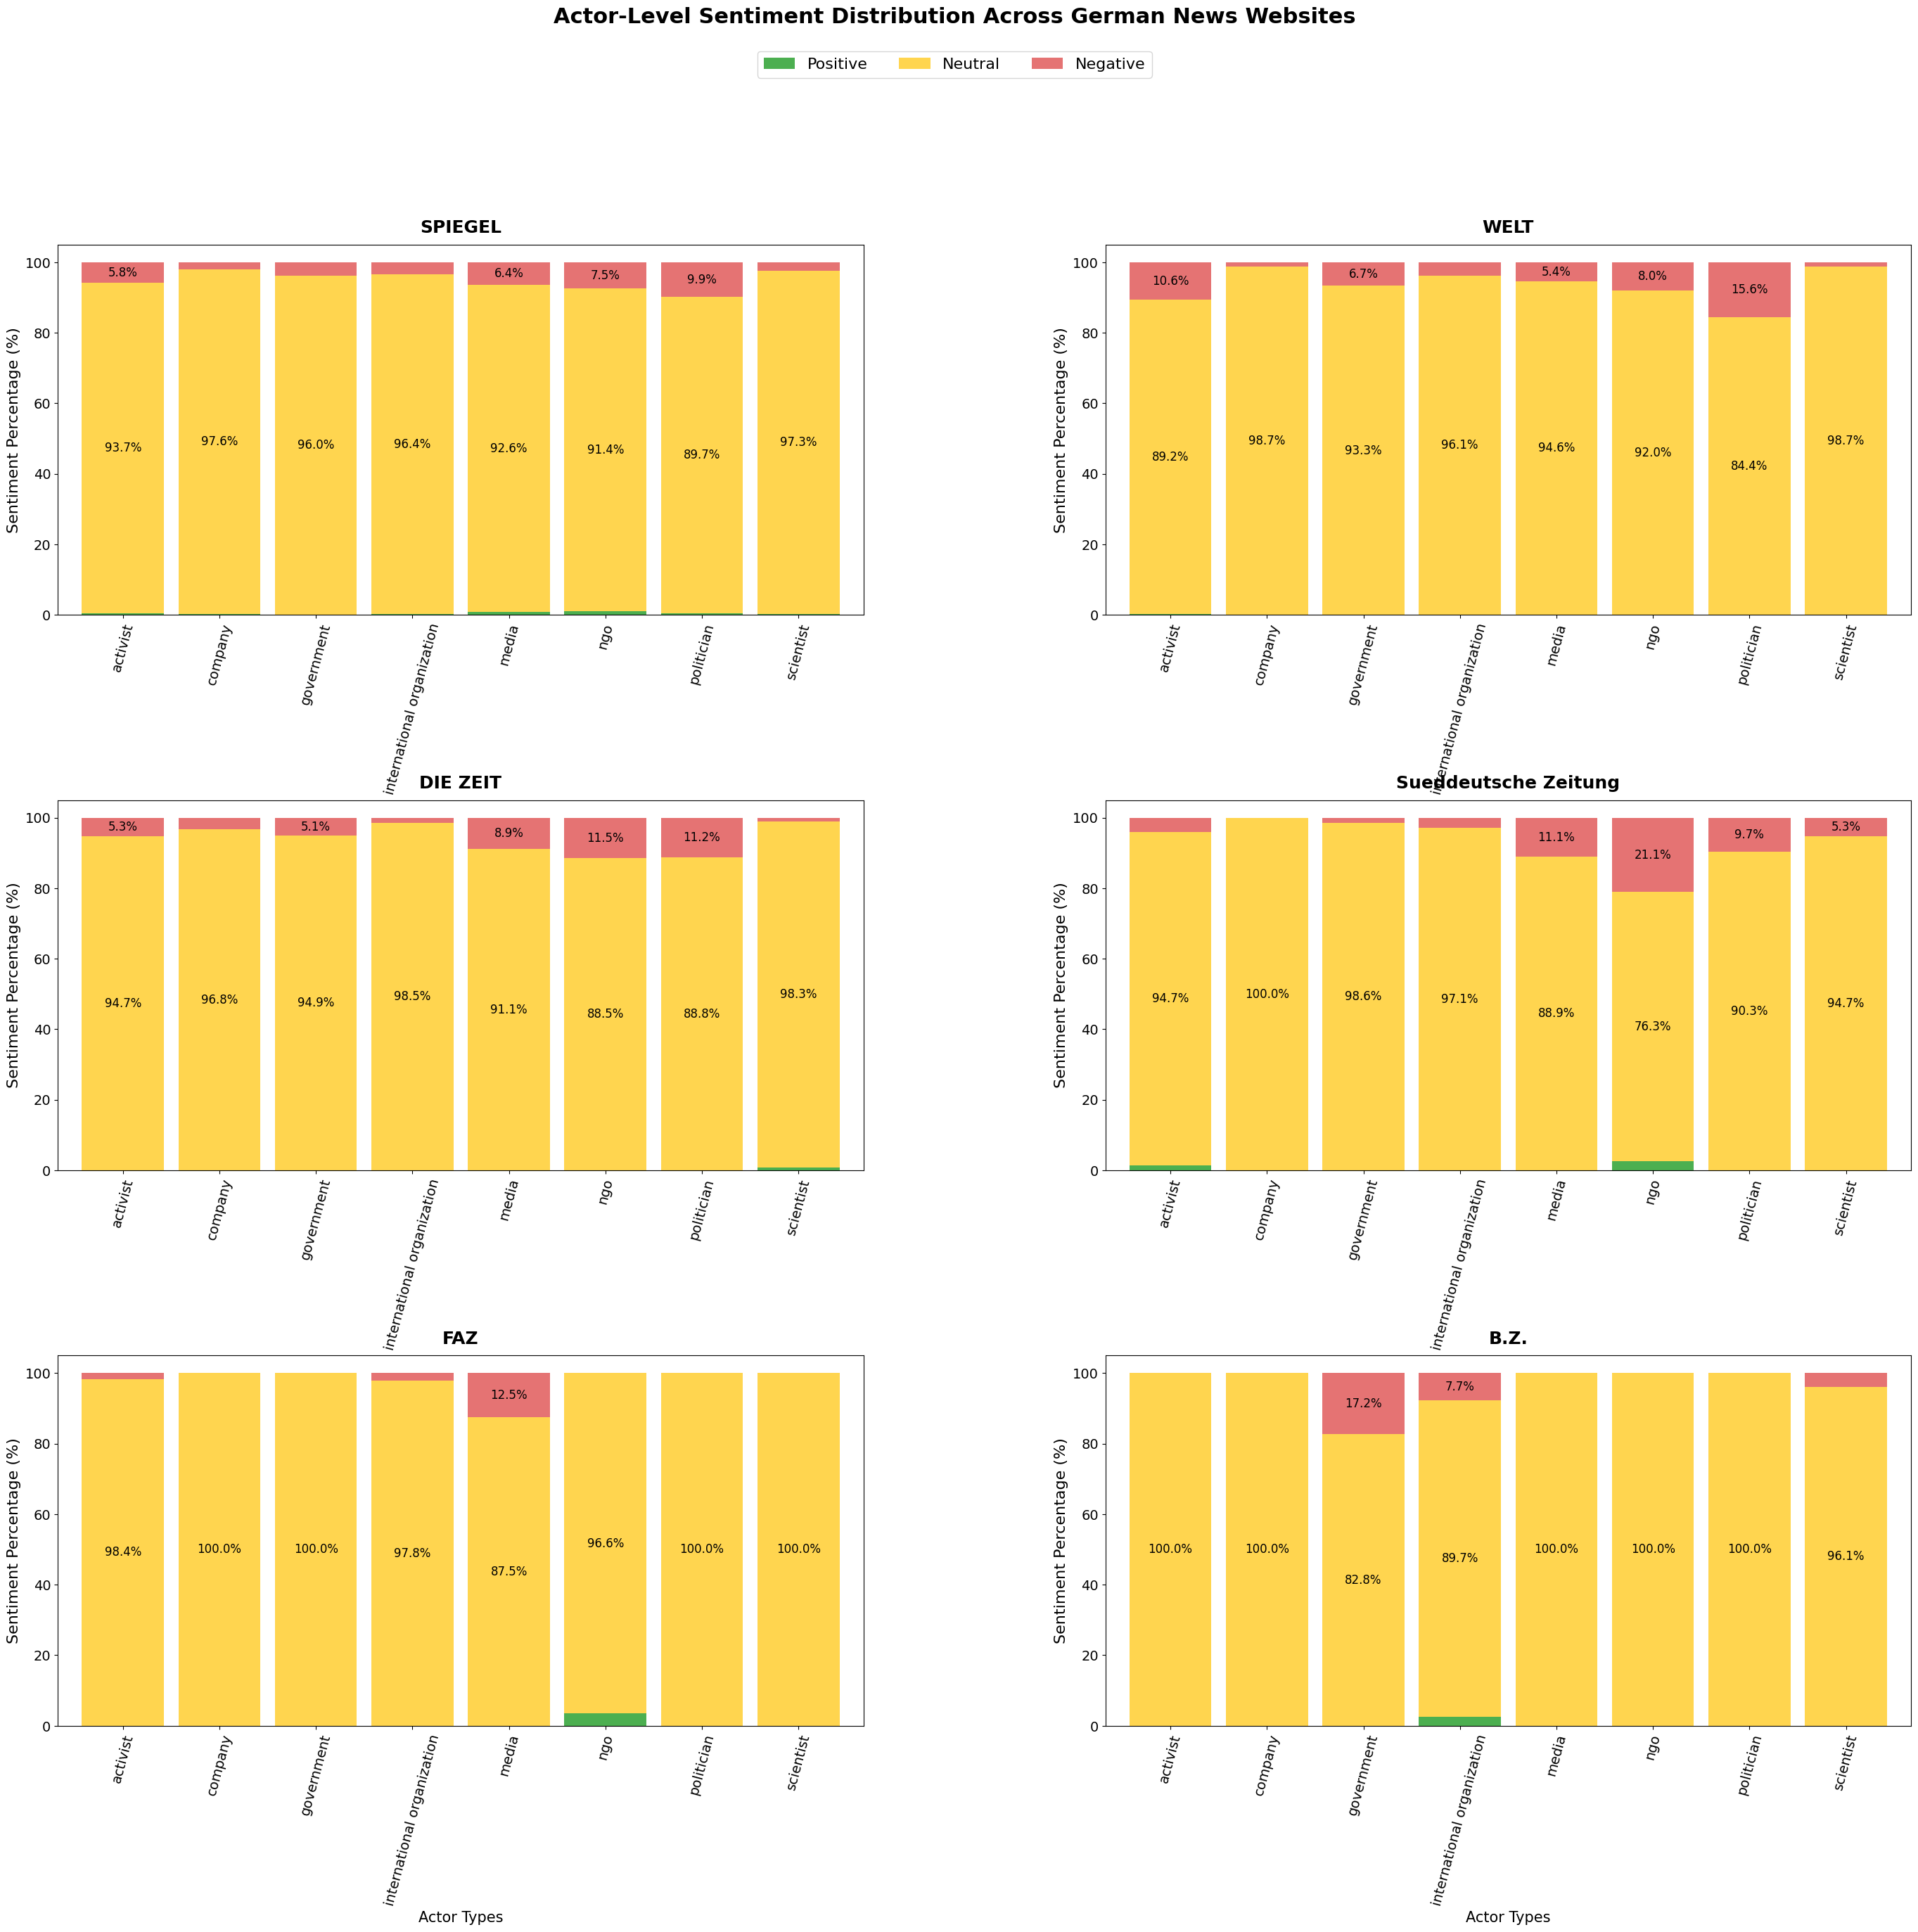

In [ ]:
df = pd.read_csv("actor_analysis.csv")
df = df[["Source", "actor_type","actor_sentiment"]].dropna().copy()
df["actor_sentiment"] = df["actor_sentiment"].str.lower().str.strip()
df["actor_type"] = df["actor_type"].astype(str).str.strip()
df["actor_type"] = df["actor_type"].str.lower().str.strip()
df = df[~df["actor_type"].isin(["other", "others", "unknown", "nan", "none", ""])]
top_sources = df["Source"].value_counts().head(6).index.tolist()
df = df[df["Source"].isin(top_sources)]
fig, axes = plt.subplots(3, 2, figsize=(34, 26))
axes = axes.flatten()
colors = ["#4CAF50", "#FFD54F", "#E57373"]
for i, source in enumerate(top_sources):
    sub_df = df[df["Source"] == source]
    count_df = (sub_df.groupby(["actor_type", "actor_sentiment"]).size().unstack(fill_value=0))
    for col in ["positive", "neutral", "negative"]:
        if col not in count_df.columns:
            count_df[col] = 0
    count_df = count_df[["positive", "neutral", "negative"]]
    percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100
    percent_df = percent_df.sort_index()
    percent_df.plot(kind="bar", stacked=True, ax=axes[i], color=colors, legend=False, width=0.85)
    for container in axes[i].containers:
        labels = []
        for v in container.datavalues:
            if v > 5:
                labels.append(f"{v:.1f}%")
            else:
                labels.append("")
        axes[i].bar_label(container, labels=labels, label_type="center", fontsize=12)
    axes[i].set_title(source, fontsize=18, fontweight="bold", pad=12)
    axes[i].set_xlabel("Actor Types", fontsize=15)
    axes[i].set_ylabel("Sentiment Percentage (%)", fontsize=16)
    axes[i].tick_params(axis='x', rotation=75, labelsize=14)
    axes[i].tick_params(axis='y', labelsize=14)
fig.legend(["Positive", "Neutral", "Negative"], loc="upper center", ncol=3, fontsize=16, bbox_to_anchor=(0.5, 1.03))
plt.suptitle("Actor-Level Sentiment Distribution Across German News Websites",fontsize=22, fontweight="bold", y=1.05)
plt.subplots_adjust(hspace=0.5, wspace=0.3, top=0.92)
plt.savefig("actor_sentiment_analysis.png", dpi=500, bbox_inches="tight")
plt.show()

**RQ5: What are the most foccused actors for German News Media?**

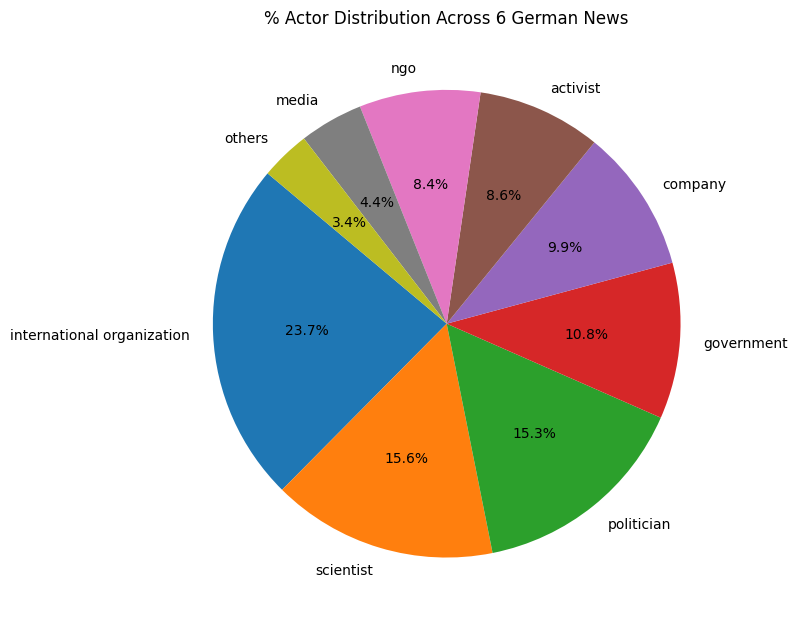

In [ ]:
df = pd.read_csv("actor_analysis.csv")
df = df[["actor_type"]].dropna().copy()
df["actor_type"] = df["actor_type"].astype(str).str.lower().str.strip()
df = df[df["actor_type"] != "other"]
counts = df["actor_type"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index,autopct="%1.1f%%",startangle=140)
plt.title("% Actor Distribution Across 6 German News")
plt.tight_layout()
plt.savefig("overall_actor_distribution.png", dpi=300, bbox_inches="tight")
plt.show()